In [40]:
%pip install seaborn 

Note: you may need to restart the kernel to use updated packages.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
lst  = [1,2,3,4]
b = []
for a in lst:
    a = a * 2
    b.append(a)

In [17]:
b

[2, 4, 6, 8]

In [18]:
a = np.array(lst)

In [19]:
a

array([1, 2, 3, 4])

In [21]:
a*2

array([2, 4, 6, 8])

# Detecting and Removing Outliers using `BoxPlot` 

<img src="https://miro.medium.com/1*0MPDTLn8KoLApoFvI0P2vQ.png" alt="image" width="600" height="350">

In [33]:
df = pd.read_excel("emp.xlsx")

In [34]:
df.columns

Index(['Unnamed: 0', 'Serial', 'Emp_ID', 'Designation', 'Department', 'Age',
       'Salary'],
      dtype='str')

In [35]:
df = df.drop(["Unnamed: 0"],axis=1)

In [36]:
df.head()

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50,200000.000000
1,1,1107,Officer,IT,30,80000.000000
2,2,1203,Officer,HR,28,94173.913043
3,3,1005,Manager,HR,45,120000.000000
4,4,2123,Office Boy,Accounts,27,45000.000000


In [37]:
df

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50,200000.000000
1,1,1107,Officer,IT,30,80000.000000
2,2,1203,Officer,HR,28,94173.913043
3,3,1005,Manager,HR,45,120000.000000
4,4,2123,Office Boy,Accounts,27,45000.000000
5,5,2451,Accountant,Production,34,100000.000000
6,6,1111,Accountant,Accounts,35,110000.000000
7,7,1001,Officer,IT,25,75000.000000
8,8,1234,Manager,IT,23,94173.913043
9,9,2156,Engineer,Production,45,89000.000000


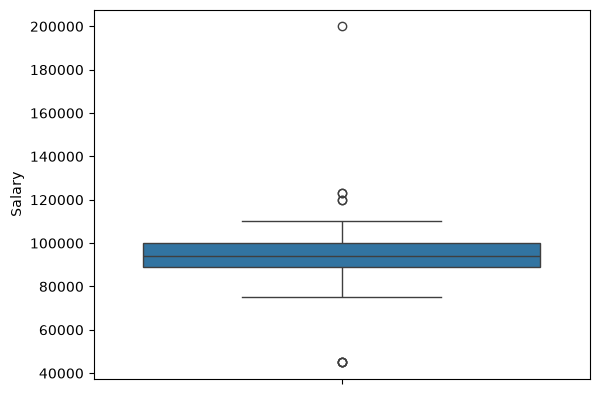

In [43]:
sns.boxplot(df.Salary)
plt.show()

In [44]:
q1 = np.percentile(df.Salary,25)
q1

np.float64(89000.0)

In [45]:
q3 = np.percentile(df.Salary,75)
q3

np.float64(100000.0)

In [46]:
iqr = q3-q1

In [47]:
iqr

np.float64(11000.0)

In [48]:
min = q1 - 1.5 * iqr
min

np.float64(72500.0)

In [50]:
max = q3 + 1.5 * iqr
max

np.float64(116500.0)

In [76]:
def Percentile_Summary(column):
    q1 = np.percentile(column , 25)
    q3 = np.percentile(column , 75)
    iqr = q3 - q1

    min = q1 - 1.5 * iqr
    max = q3 + 1.5 * iqr

    res = f"-----Percentile Summary-----\nIQR : {iqr}\nQ1 : {q1}\nQ3 : {q3}\nMin : {min}\nMax : {max}"

    return res

In [77]:
print(Percentile_Summary(df.Salary))

-----Percentile Summary-----
IQR : 11000.0
Q1 : 89000.0
Q3 : 100000.0
Min : 72500.0
Max : 116500.0


In [78]:
def detect_outlier(column):
    q1 = np.percentile(column , 25)
    q3 = np.percentile(column , 75)
    iqr = q3 - q1

    lower_boundary = q1 - 1.5 * iqr
    upper_boundary = q3 + 1.5 * iqr

    return lower_boundary , upper_boundary


In [89]:
df[(df.Salary<detect_outlier(df.Salary)[0]) | (df.Salary>detect_outlier(df.Salary)[1])]

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50,200000.0
3,3,1005,Manager,HR,45,120000.0
4,4,2123,Office Boy,Accounts,27,45000.0
11,11,3214,Accountant,Account,49,123000.0
17,17,2123,Office Boy,Accounts,27,45000.0
18,18,1005,Manager,HR,45,120000.0
19,19,2123,Office Boy,Accounts,27,45000.0
21,21,3214,Accountant,Account,49,123000.0
25,25,2123,Office Boy,Accounts,27,45000.0


In [92]:
df[(df.Salary>detect_outlier(df.Salary)[0]) & (df.Salary<detect_outlier(df.Salary)[1])]

,Serial,Emp_ID,Designation,Department,Age,Salary
1,1,1107,Officer,IT,30,80000.000000
2,2,1203,Officer,HR,28,94173.913043
5,5,2451,Accountant,Production,34,100000.000000
6,6,1111,Accountant,Accounts,35,110000.000000
7,7,1001,Officer,IT,25,75000.000000
8,8,1234,Manager,IT,23,94173.913043
9,9,2156,Engineer,Production,45,89000.000000
10,10,6543,Officer,Production,29,100000.000000
12,12,2156,Engineer,Production,45,89000.000000
13,13,1098,Officer,IT,25,100000.000000


# Duplicate Data Detection

In [119]:
df

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50,200000.000000
1,1107,Officer,IT,30,80000.000000
2,1203,Officer,HR,28,94173.913043
3,1005,Manager,HR,45,120000.000000
4,2123,Office Boy,Accounts,27,45000.000000
5,2451,Accountant,Production,34,100000.000000
6,1111,Accountant,Accounts,35,110000.000000
7,1001,Officer,IT,25,75000.000000
8,1234,Manager,IT,23,94173.913043
9,2156,Engineer,Production,45,89000.000000


In [124]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop("Serial",axis=1,inplace=True)

In [125]:
df[df.duplicated()]

,Emp_ID,Designation,Department,Age,Salary


In [110]:
df = df.drop_duplicates()

In [114]:
df.duplicated().sum()

np.int64(0)

In [106]:
df[df.duplicated(subset=["Designation","Salary"])]

,Emp_ID,Designation,Department,Age,Salary
12,2156,Engineer,Production,45,89000.000000
13,1098,Officer,IT,25,100000.000000
15,1222,Officer,Production,25,94173.913043
16,2156,Engineer,Production,45,89000.000000
17,2123,Office Boy,Accounts,27,45000.000000
18,1005,Manager,HR,45,120000.000000
19,2123,Office Boy,Accounts,27,45000.000000
20,6543,Officer,Production,29,100000.000000
21,3214,Accountant,Account,49,123000.000000
22,2156,Engineer,Production,45,89000.000000


In [ ]:
df.drop_duplicates(subset=["Designation","Salary"])

# Transforming Data Using a Function or Mapping

In [127]:
designation_mapping = ["man","off","eng","ofb","acnt"]

In [129]:
designation_mapping = {
    "Manager" : "Man",
    "Officer" : "Off",
    "Engineer" : "Eng",
    "Office Boy" : "Ofb",
    "Accountant" : "Acc",
}

In [130]:
df["Short_Code"] = df.Designation.map(designation_mapping)

In [131]:
df

,Emp_ID,Designation,Department,Age,Salary,Short_Code
0,1101,Manager,Accounts,50,200000.000000,Man
1,1107,Officer,IT,30,80000.000000,Off
2,1203,Officer,HR,28,94173.913043,Off
3,1005,Manager,HR,45,120000.000000,Man
4,2123,Office Boy,Accounts,27,45000.000000,Ofb
5,2451,Accountant,Production,34,100000.000000,Acc
6,1111,Accountant,Accounts,35,110000.000000,Acc
7,1001,Officer,IT,25,75000.000000,Off
8,1234,Manager,IT,23,94173.913043,Man
9,2156,Engineer,Production,45,89000.000000,Eng
